In [28]:
import os, yaml, sys
import numpy as np
import matplotlib.pyplot as plt
import h5py
from IPython.display import clear_output
import random
ENV = os.getenv("MY_ENV", "dev")
with open("../../config.yaml", "r") as f:
    config = yaml.safe_load(f)
paths = config[ENV]["paths"]
sys.path.append(paths["src_path"])
sys.path.append(paths["useful_stuff_path"])
from useful_stuff.general_utils.utils import TimeSeries, print_wise, get_lagplot
from useful_stuff.image_processing.computational_models import get_relevant_output_layers
from image_processing.gaze_dep_models import save_ANN_features
from useful_stuff.general_utils.RSA import dRSA
from useful_stuff.general_utils.regression import dyn_linear_encoding
from useful_stuff.general_utils.II import dynInformationImbalance
from project_specific_utils.dataloader import load_concat_regressout_meg, load_concat_regressout_mod 
from project_specific_utils.subsampling_lagged_comparisons import save_lagged_comparisons
# from image_processing.gaze_dep_models import save_ANN_features


In [4]:
from dataclasses import dataclass, field

@dataclass
class Cfg:
    sub_num = 3
    run = 1
    neu_fs = 100
    mod_fs = 23.976
    model_name = "dino_v3_l";
    layer_name = "classifier.2";
    n_components = 1000
    pooling = "all"
    sq_side = 384
    downsampled_sq_size = 50
    sensors_group = 'occ'
    time_points = 50
    pseudotrials_n = 500
    max_lag=100
    pkg="timm"
cfg = Cfg()
layers = get_relevant_output_layers(cfg.model_name, pkg=cfg.pkg)

In [ ]:
from scipy.io import savemat
def lagged_encoding_comparisons(paths, rank, full_model_name, n, analysis_type, sub_num, sensors_group, repetition, neu_fs, mod_fs, regression_type, PCs_model_used, score_metric, sq_side, regress_out_gaze, n_model_components,  pooling="all",):
    if not cfg.regress_out_gaze:
        cfg.regress_out_gaze = "0"
    p = save_lagged_comparisons(paths, analysis_type, sub_num, sensors_group, repetition, full_model_name,  neu_fs, regression_type=regression_type, PCs_used=PCs_model_used, score_metric=score_metric, sq_side=sq_side, regress_out_gaze=regress_out_gaze)
    if os.path.exists(p):
        print(f"{p} already exists")
        return None
    m = load_concat_regressout_mod(paths, sub_num, save_ANN_features, full_model_name, repetition, mod_fs, neu_fs, *(sq_side, n_model_components, pooling), regress_out_gaze=False, gaze_dep=True, gaze_fs=50, rank=rank,)
    m_reduced = TimeSeries(m.get_array()[:PCs_model_used, :, np.newaxis], neu_fs)
    regression_obj = dyn_linear_encoding(regression_type, 'kf', cfg.max_lag, score_type=score_metric, n_splits=5)
    regression_score = regression_obj.crossvalidate_general_dyn(m_reduced, n)
    savemat(p, {"regression": regression_score})
    print_wise(f"{full_model_name} saved at {p}")
    return None

In [ ]:
repetitions = [0,1]
rank = 0
for i_rep in repetitions:
    n = load_concat_regressout_meg(paths, cfg.sub_num, i_rep, cfg.sensors_group, cfg.neu_fs, cfg.gaze_fs, cfg.regress_out_gaze, cfg.PCs_to_regress_out, timepts_to_regress_out=cfg.timepts_to_regress_out, rank=rank)
    for l in get_relevant_output_layers(cfg.model_name, pkg=cfg.pkg):
        full_model_name = f"{cfg.model_name}_{l}"
        lagged_encoding_comparisons(paths, rank, full_model_name, n, cfg.analysis_type, cfg.sub_num, cfg.sensors_group, i_rep, ...) # cfg.iterations_n, cfg.pseudotrial_len, cfg.neu_fs, mod_fs, model_len, cfg.signal_metric, cfg.model_metric, cfg.pseudotrials_n, cfg.sq_side, cfg.regress_out_gaze, cfg.n_model_components)

array([[ 0.6856762 ,  1.1696305 , -0.0280956 , ...,  0.5203326 ,
        -0.5309613 , -1.6937444 ],
       [ 0.64322263,  1.1325284 ,  0.43688443, ..., -0.19967389,
        -0.58224326, -1.2485479 ],
       [ 0.7964894 ,  1.3238682 ,  0.77518123, ..., -0.9219232 ,
        -0.78518206, -0.9932766 ],
       ...,
       [ 0.48687273,  0.78968614, -0.32213855, ...,  0.92224026,
        -0.6113072 , -1.8963338 ],
       [ 0.98406327,  2.1079865 ,  1.3975663 , ...,  4.02312   ,
         3.7369335 ,  2.9418375 ],
       [ 0.3077566 ,  1.6844656 ,  2.309521  , ...,  3.3860056 ,
         3.7011027 ,  4.2226    ]], shape=(41, 87483), dtype=float32)

In [20]:
sub_num = 3; run = 1;
tot_crossval = []
for l in layers[::5]:
    try:
        print_wise(f"starting layer {l}")
        ANN_features_path = save_ANN_features(paths, f"{cfg.model_name}_{l}", sub_num, run, round(cfg.mod_fs), cfg.sq_side, cfg.n_components,  cfg.pooling,)
        with h5py.File(ANN_features_path, "r") as f:
            features = TimeSeries(f['vecrep'][:, :], cfg.mod_fs)
            features.resample(cfg.neu_fs)
        features_reduced = TimeSeries(features.get_array()[:50, :], cfg.mod_fs)
        X = TimeSeries(features_reduced.get_array()[:,:,np.newaxis], neu_rep1.get_fs())
        Y = TimeSeries(neu_rep1.get_array()[:,:len(features_reduced),np.newaxis], neu_rep1.get_fs())
        model = dyn_linear_encoding('ridge', 'kf', cfg.max_lag, score_type="corr", n_splits=5)
        # X.z_score_feats()
        s = model.crossvalidate_general_dyn(X, Y)
        tot_crossval.append(s)
    except FileNotFoundError:
            print_wise(f"{l} not found")
os.system('afplay /System/Library/Sounds/Ping.aiff')

15:33:15 - starting layer layer.0.mlp.down_proj
15:41:15 - starting layer layer.5.mlp.down_proj
15:49:17 - starting layer layer.10.mlp.down_proj
15:57:19 - starting layer layer.15.mlp.down_proj
16:05:23 - starting layer layer.20.mlp.down_proj


0

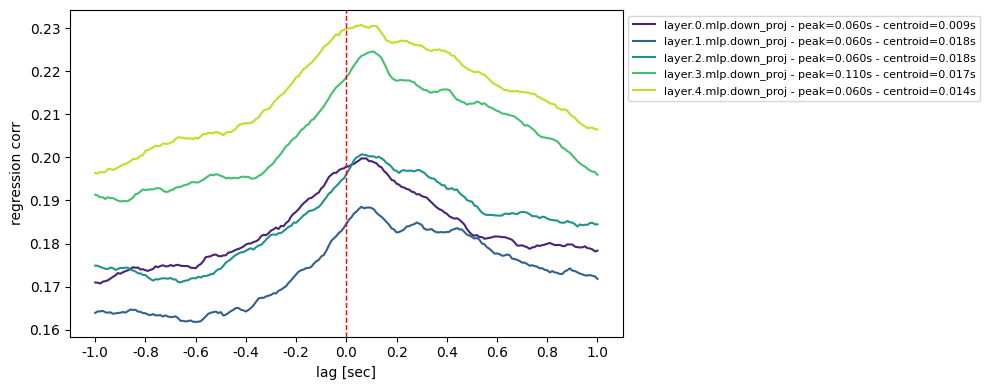

In [26]:
from useful_stuff.general_utils.plots import truncate_colormap
peaks = []
centroids = []
ticks = np.arange(-cfg.max_lag, cfg.max_lag + 1, 20)
ticks_labels = np.round(ticks / cfg.neu_fs, 2)
ticks += cfg.max_lag
plt.figure(figsize=(10, 4))
lags = np.arange(-cfg.max_lag, cfg.max_lag + 1)
cmap = truncate_colormap(plt.cm.viridis)  # or "plasma", "coolwarm", etc.
colors = cmap(np.linspace(0, 1, len(tot_crossval)))
for idx, l in enumerate(tot_crossval):
    curve = np.squeeze(l.get_array())
    weights = l.get_array().copy()
    weights[weights < 0] = 0  # optional but recommended
    weights = np.squeeze(l.get_array()).copy()
    weights[weights < 0] = 0

    if np.sum(weights) == 0:
        centroid_sec = np.nan
    else:
        centroid_sec = np.sum((lags / cfg.neu_fs) * weights) / np.sum(weights)

    centroids.append(centroid_sec)
    peak_sec = (np.argmax(curve) - cfg.max_lag) / cfg.neu_fs
    peaks.append(peak_sec)

    plt.plot(
        curve,
        label=f"{layers[idx]} - peak={peak_sec:.3f}s - centroid={centroid_sec:.3f}s",
        color=colors[idx]
    )
plt.xticks(ticks, ticks_labels)
plt.axvline(cfg.max_lag, color="r", linestyle="--", linewidth=1)
plt.xlabel("lag [sec]")
plt.ylabel("regression corr")
plt.legend(fontsize=8, loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()

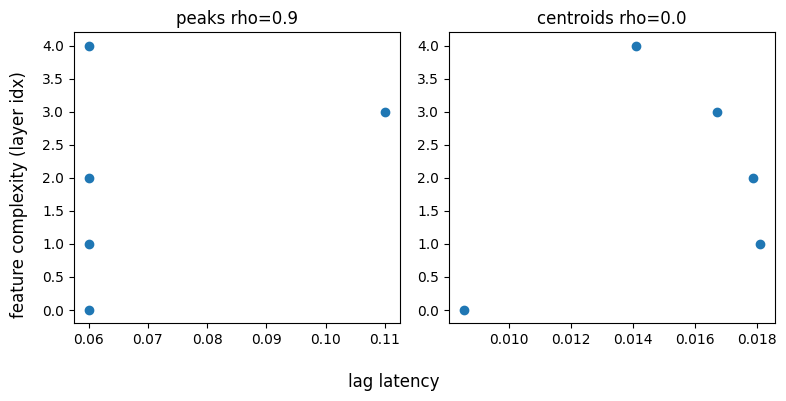

In [27]:
from useful_stuff.general_utils.utils import spearman
max_lag = cfg.max_lag
tick_step = 40
fig, ax = plt.subplots(1,2, figsize=(8, 4))
ax[0].scatter(np.array(peaks), np.arange(len(peaks)))
rho = np.round(spearman(np.arange(len(peaks)), np.array(peaks)),2)
ax[0].set_title(f"peaks rho={rho}")
ax[1].scatter(centroids, np.arange(len(centroids)));
rho = np.round(spearman(np.arange(len(peaks)), np.array(centroids)), 2)
ax[1].set_title(f"centroids rho={rho}")
fig.supxlabel("lag latency")
fig.supylabel("feature complexity (layer idx)")
fig.tight_layout()

Text(0.5, 1.0, 'occ')

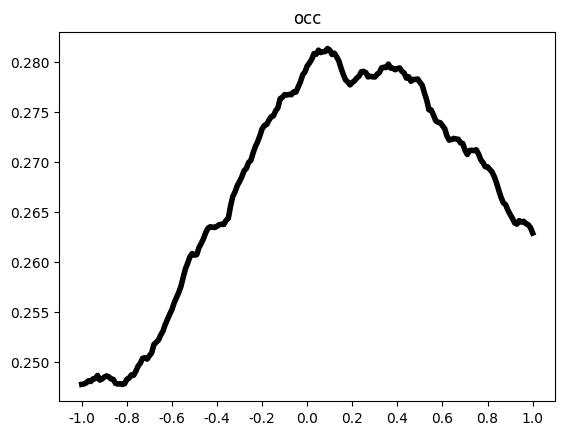

In [22]:
import matplotlib.pyplot as plt
import numpy as np
tick_step = 20
data = s.get_array()
n_lines = data.shape[0]
max_lag = cfg.max_lag
fs = s.get_fs()
ticks = np.arange(-max_lag, max_lag + 1, tick_step)
ticks_labels = np.round(ticks / fs, 2)
ticks+= max_lag
cmap = plt.get_cmap("viridis")  # choose your cmap

for i in range(n_lines):
    color = cmap(i / n_lines)
    plt.plot(data.T[:, i], color=color, label=labels1[i])
plt.xticks(ticks, ticks_labels)
# mean in black (on top)
plt.plot(data.mean(axis=0), linewidth=4, color="k")
plt.title(cfg.sensors_group)

# plt.legend(fontsize=6)